# mmFall Fall Detection — Representation 3: Native 3D Point Set (PointNet++)

This notebook processes the **Representation 3 (Unordered Native 3D Point Cloud Set)** format for mmWave radar fall detection, training a **PointNet / PointNet++** geometric architecture in PyTorch as defined in the research plan (*'Comparing mmWave Radar Data Formats for Fall Detection' by Joey van der Poel*).

---

### 📡 Representation & Model Specifications:
- **Representation Format**: Unordered Point Matrix $P \in \mathbb{R}^{5 \times 640}$.
- **Point Attributes**: 5 Channels $[\Delta x, \Delta y, z, v_{\text{doppler}}, t]$.
- **Target Geometry**: Directly consumes exact 3D spatial layout without converting points to 2D pixel grids.
- **Model Backbone**: PyTorch **PointNet / PointNet++** Geometric Feature Extractor.


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Load Preprocessed Representation 3 Tensors
preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../../datasets/preprocessed")
X_rep3 = np.load(preproc_dir / "X_rep3_pointset.npy") # Shape: (1182, 5, 640)
y_rep3 = np.load(preproc_dir / "y_rep3_pointset.npy") # Shape: (1182,)

print(f"Loaded Representation 3 Native Point Set Tensor: {X_rep3.shape}")
print(f"Labels: {np.bincount(y_rep3.astype(int))} (0 = ADL, 1 = Fall)")


Loaded Representation 3 Native Point Set Tensor: (1182, 5, 640)
Labels: [591 591] (0 = ADL, 1 = Fall)


C:\Users\joeyw\AppData\Local\Temp\ipykernel_10868\1404381348.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\joeyw\AppData\Local\Temp\ipykernel_10868\1404381348.py:20: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


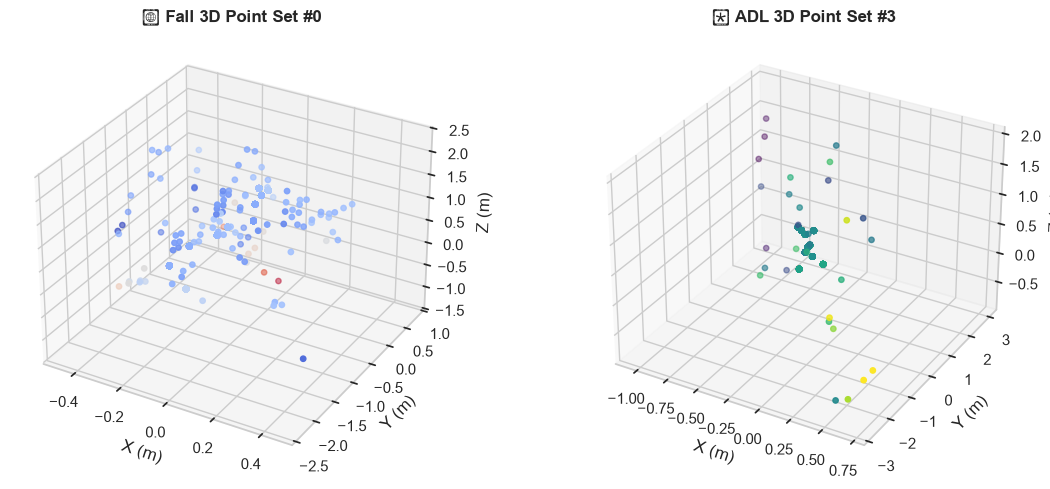

In [2]:
# Visualize Sample 3D Point Cloud Sequences
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

fall_idx = np.where(y_rep3 == 1)[0][0]
adl_idx = np.where(y_rep3 == 0)[0][0]

pts_fall = X_rep3[fall_idx] # (5, 640)
pts_adl = X_rep3[adl_idx]   # (5, 640)

ax1.scatter(pts_fall[0], pts_fall[1], pts_fall[2], c=pts_fall[3], cmap="coolwarm", s=15)
ax1.set_title(f"🔴 Fall 3D Point Set #{fall_idx}", fontweight="bold")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)"); ax1.set_zlabel("Z (m)")

ax2.scatter(pts_adl[0], pts_adl[1], pts_adl[2], c=pts_adl[3], cmap="viridis", s=15)
ax2.set_title(f"🟢 ADL 3D Point Set #{adl_idx}", fontweight="bold")
ax2.set_xlabel("X (m)"); ax2.set_ylabel("Y (m)"); ax2.set_zlabel("Z (m)")

plt.tight_layout()
plt.show()


In [3]:
# Define PointNet Geometric Model in PyTorch
class PointNetCls(nn.Module):
    def __init__(self, in_channels=5, num_classes=2):
        super(PointNetCls, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, 1)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, 2, keepdim=False)[0]
        return self.fc(x)

# Split Train & Test Sets (80% / 20% Stratified)
X_tr, X_te, y_tr, y_te = train_test_split(X_rep3, y_rep3, test_size=0.2, random_state=42, stratify=y_rep3)
print(f"Train samples: {len(X_tr)}, Test samples: {len(X_te)}")


Train samples: 945, Test samples: 237


In [4]:
# Train PointNetCls Model with Best Model Checkpointing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PointNetCls().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

# Best Model Checkpoint Path
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "pointnet_rep3_pointset_mmfall.pth"

epochs = 15
losses, accs = [], []
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    r_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * bx.size(0)
        preds = out.argmax(dim=1)
        corr += (preds == by).sum().item()
        tot += by.size(0)
    train_loss = r_loss / tot
    train_acc = corr / tot
    losses.append(train_loss)
    accs.append(train_acc)

    # Validation step to track best model
    model.eval()
    val_loss, val_corr, val_tot = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in te_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            v_loss = criterion(out, by)
            val_loss += v_loss.item() * bx.size(0)
            val_corr += (out.argmax(dim=1) == by).sum().item()
            val_tot += by.size(0)
    val_loss /= val_tot
    val_acc = val_corr / val_tot
    scheduler.step(val_loss)

    # Checkpoint best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    print(f"Epoch [{ep+1:02d}/{epochs:02d}] Tr Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch [01/15] Loss: 0.5085, Acc: 74.71%
Epoch [02/15] Loss: 0.3610, Acc: 83.92%
Epoch [03/15] Loss: 0.3025, Acc: 86.98%
Epoch [04/15] Loss: 0.2713, Acc: 88.25%
Epoch [05/15] Loss: 0.2359, Acc: 90.37%
Epoch [06/15] Loss: 0.1913, Acc: 93.33%
Epoch [07/15] Loss: 0.1556, Acc: 94.29%
Epoch [08/15] Loss: 0.1611, Acc: 93.44%
Epoch [09/15] Loss: 0.1646, Acc: 93.86%
Epoch [10/15] Loss: 0.1341, Acc: 94.81%
Epoch [11/15] Loss: 0.1153, Acc: 95.77%
Epoch [12/15] Loss: 0.0767, Acc: 98.20%
Epoch [13/15] Loss: 0.0662, Acc: 97.57%
Epoch [14/15] Loss: 0.0500, Acc: 98.52%
Epoch [15/15] Loss: 0.0738, Acc: 97.14%


--- Representation 3 (Native 3D PointSet PointNet) Test Results ---
Test Accuracy: 89.87%
ROC-AUC Score: 0.9569
              precision    recall  f1-score   support

Non-Fall ADL       0.91      0.88      0.90       119
        Fall       0.89      0.92      0.90       118

    accuracy                           0.90       237
   macro avg       0.90      0.90      0.90       237
weighted avg       0.90      0.90      0.90       237



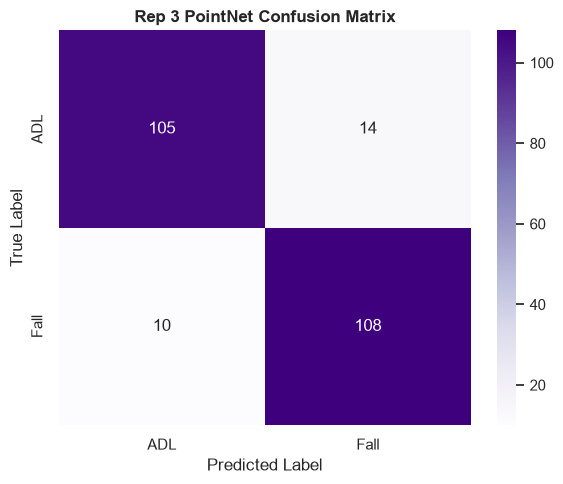

In [5]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

acc = accuracy_score(targets_list, preds_list)
auc = roc_auc_score(targets_list, probs_list)
cm = confusion_matrix(targets_list, preds_list)

print(f"--- Representation 3 (Native 3D PointSet PointNet) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print(classification_report(targets_list, preds_list, target_names=["Non-Fall ADL", "Fall"]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=["ADL", "Fall"], yticklabels=["ADL", "Fall"])
plt.title("Rep 3 PointNet Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
